In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 安装 causal-learn 库和依赖
!pip install causal-learn
# 安装画图必须的 graphviz 系统包 (Colab 必备)
!apt-get install -y graphviz libgraphviz-dev
!pip install pygraphviz pydot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 5.5 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4
0 upgraded, 12 newly installed, 0 to remove and 2 not upgraded.
Need to get 2,496 kB of archives.
After this operation, 7,963 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ScoreBased.GES import ges
from causallearn.search.FCMBased import lingam
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.utils.GraphUtils import GraphUtils
from causallearn.graph.GraphNode import GraphNode
from causallearn.graph.GeneralGraph import GeneralGraph
from causallearn.graph.Edge import Edge
from causallearn.graph.Endpoint import Endpoint

import warnings
warnings.filterwarnings('ignore')

drive_data_folder = '/content/drive/MyDrive/Colab Notebooks/DDA4210/DataSet'
datasets = {'Linear_MICE': 'NHANES_Imp_Linear.csv', 'Random_Forest_MICE': 'NHANES_Imp_RF.csv', 'Median_Baseline': 'NHANES_Imp_Median.csv'}
selected_nodes = ['Age', 'Gender', 'Income_Poverty_Ratio', 'BMI', 'Sleep_Hours', 'Sedentary_Mins', 'Cancer_History', 'PHQ9_Score']

def matrix_to_cg(labels, adj_matrix, algo):
    nodes = [GraphNode(name) for name in labels]
    G = GeneralGraph(nodes)

    # 提取先验知识节点的索引
    age_idx = labels.index('Age')
    gender_idx = labels.index('Gender')

    # 定义判断是否违背先验规则的内部函数
    def is_forbidden(source_idx, target_idx):
        # 没有任何东西能指向 年龄 或 性别
        if target_idx == age_idx: return True
        if target_idx == gender_idx: return True
        return False

    for i in range(len(labels)):
        for j in range(len(labels)):
            if algo == "GES":
                if adj_matrix[i, j] == -1 and adj_matrix[j, i] == 1:
                    # 原始 GES 认为是 i -> j
                    if not is_forbidden(i, j): # 如果不违背常识，就加上这条边
                        G.add_edge(Edge(nodes[i], nodes[j], Endpoint.TAIL, Endpoint.ARROW))

                elif adj_matrix[i, j] == -1 and adj_matrix[j, i] == -1 and i < j:
                    # 原始 GES 认为是无向边 i - j
                    forbidden_i_to_j = is_forbidden(i, j)
                    forbidden_j_to_i = is_forbidden(j, i)

                    # 利用先验知识给无向边定方向！
                    if forbidden_i_to_j and not forbidden_j_to_i:
                        G.add_edge(Edge(nodes[j], nodes[i], Endpoint.TAIL, Endpoint.ARROW))
                    elif forbidden_j_to_i and not forbidden_i_to_j:
                        G.add_edge(Edge(nodes[i], nodes[j], Endpoint.TAIL, Endpoint.ARROW))
                    else:
                        # 如果两边都不违背常识，就保留无向边
                        G.add_edge(Edge(nodes[i], nodes[j], Endpoint.TAIL, Endpoint.TAIL))

            elif algo == "LiNGAM":
                # LiNGAM 矩阵：adj_matrix[i, j] != 0 表示 j -> i
                if adj_matrix[i, j] != 0:
                    source = j
                    target = i
                    if not is_forbidden(source, target): # 如果不违背常识，才加上这条边
                        G.add_edge(Edge(nodes[source], nodes[target], Endpoint.TAIL, Endpoint.ARROW))
    return G

连续得分: PC 算法


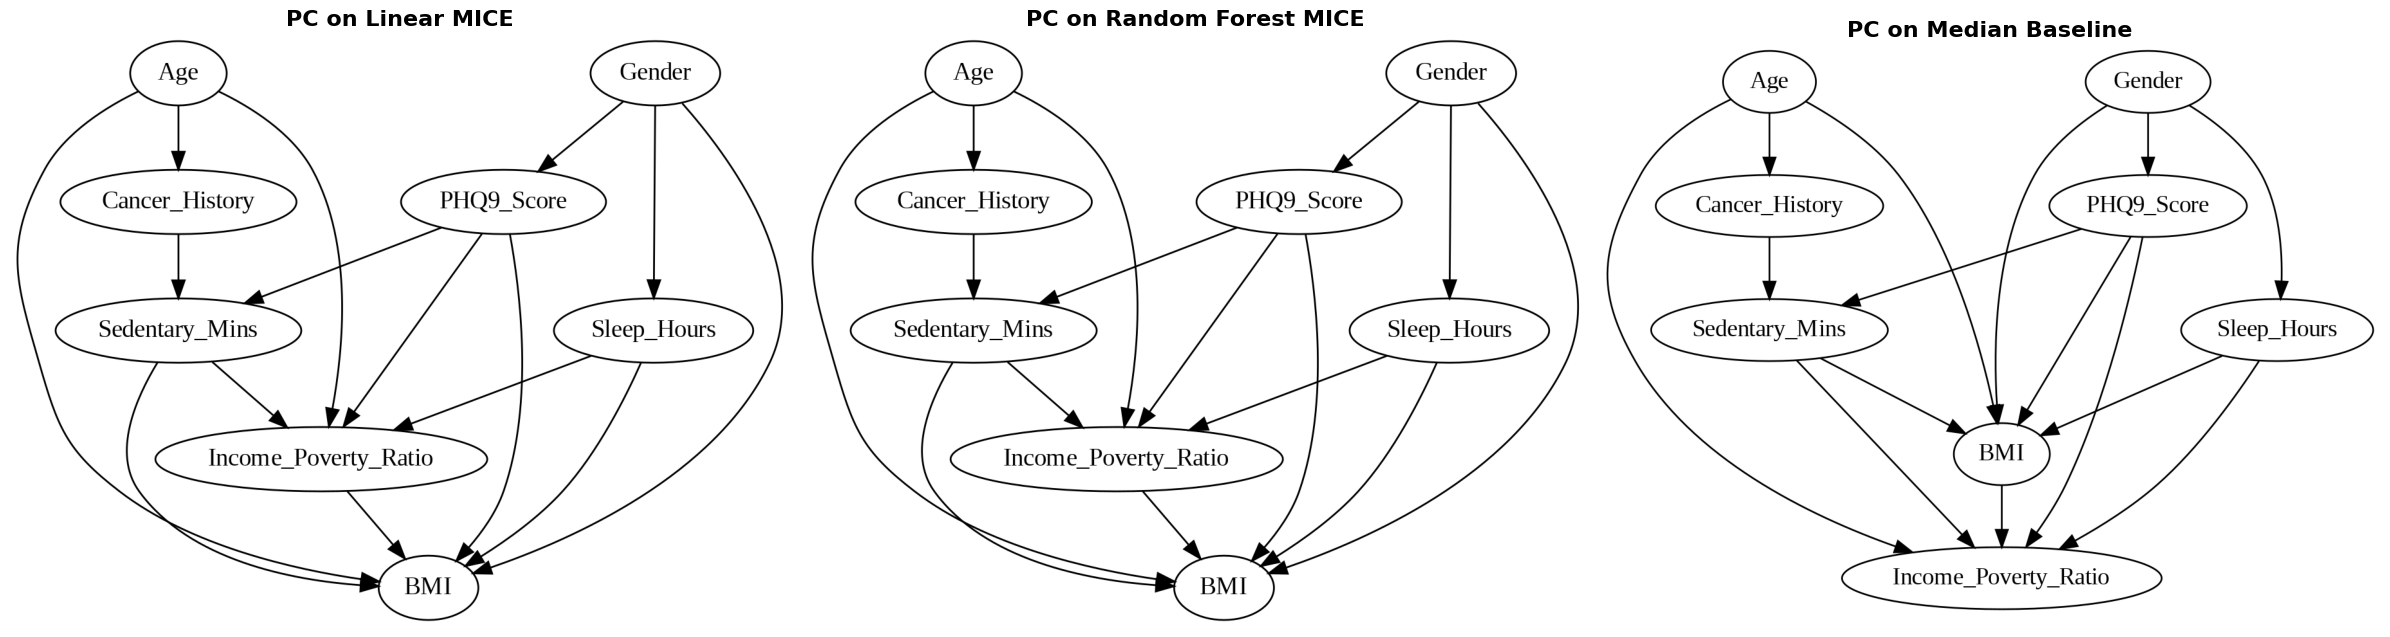

In [ ]:
print("连续得分: PC 算法")
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for idx, (name, filename) in enumerate(datasets.items()):
    df = pd.read_csv(os.path.join(drive_data_folder, filename))[selected_nodes]
    data_np = df.to_numpy()
    labels = df.columns.tolist()

    cg_init = pc(data_np, alpha=0.05, indep_test='fisherz', show_progress=False)
    nodes = cg_init.G.get_nodes()
    bk = BackgroundKnowledge()
    age_idx, gender_idx, cancer_idx = labels.index('Age'), labels.index('Gender'), labels.index('Cancer_History')
    for i in range(len(nodes)):
        if i != age_idx: bk.add_forbidden_by_node(nodes[i], nodes[age_idx])
        if i != gender_idx: bk.add_forbidden_by_node(nodes[i], nodes[gender_idx])
    bk.add_forbidden_by_node(nodes[cancer_idx], nodes[age_idx])

    cg_bk = pc(data_np, alpha=0.05, indep_test='fisherz', background_knowledge=bk, show_progress=False)

    pyd = GraphUtils.to_pydot(cg_bk.G, labels=labels)
    save_path = os.path.join(drive_data_folder, f'C4_PC_{name}.png')
    pyd.write_png(save_path)

    img = mpimg.imread(save_path)
    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(f"PC on {name.replace('_', ' ')}", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

连续得分: GES 算法...


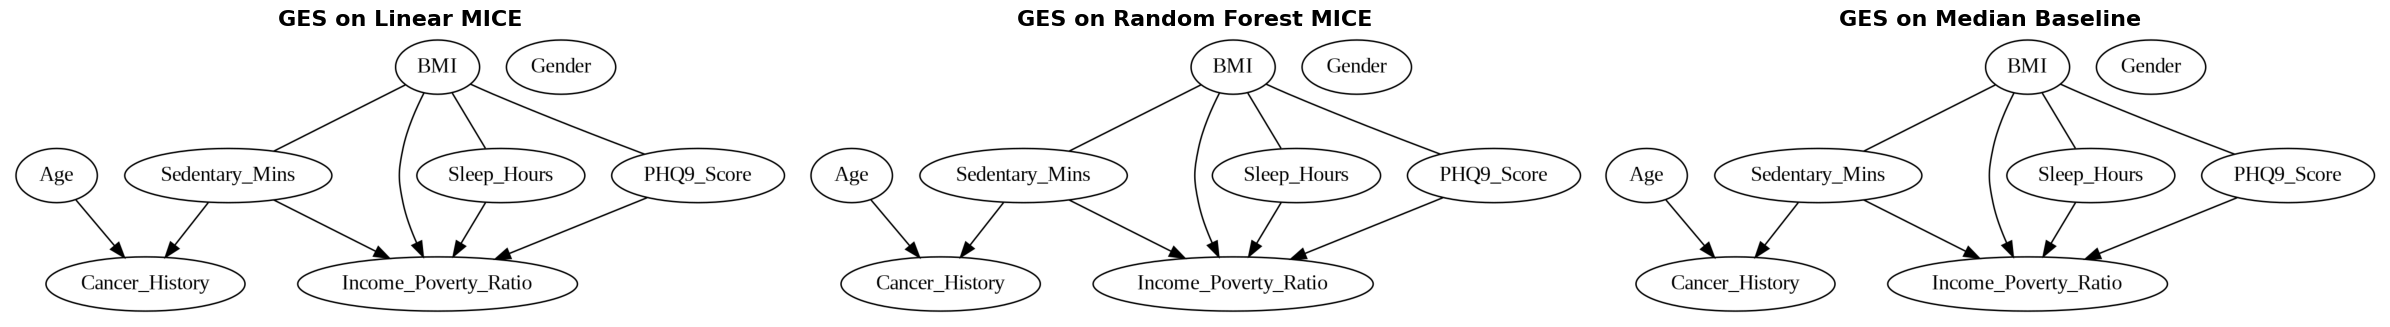

In [ ]:
print("连续得分: GES 算法...")
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for idx, (name, filename) in enumerate(datasets.items()):
    df = pd.read_csv(os.path.join(drive_data_folder, filename))[selected_nodes]
    data_np = df.to_numpy()
    labels = df.columns.tolist()

    Record = ges(data_np, 'local_score_BIC')
    ges_mat = Record['G'].graph

    # 使用自定义函数转换为标准格式并画图
    G_ges = matrix_to_cg(labels, ges_mat, "GES")
    pyd = GraphUtils.to_pydot(G_ges, labels=labels)
    save_path = os.path.join(drive_data_folder, f'C4_GES_{name}.png')
    pyd.write_png(save_path)

    img = mpimg.imread(save_path)
    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(f"GES on {name.replace('_', ' ')}", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

连续得分: LiNGAM 算法...


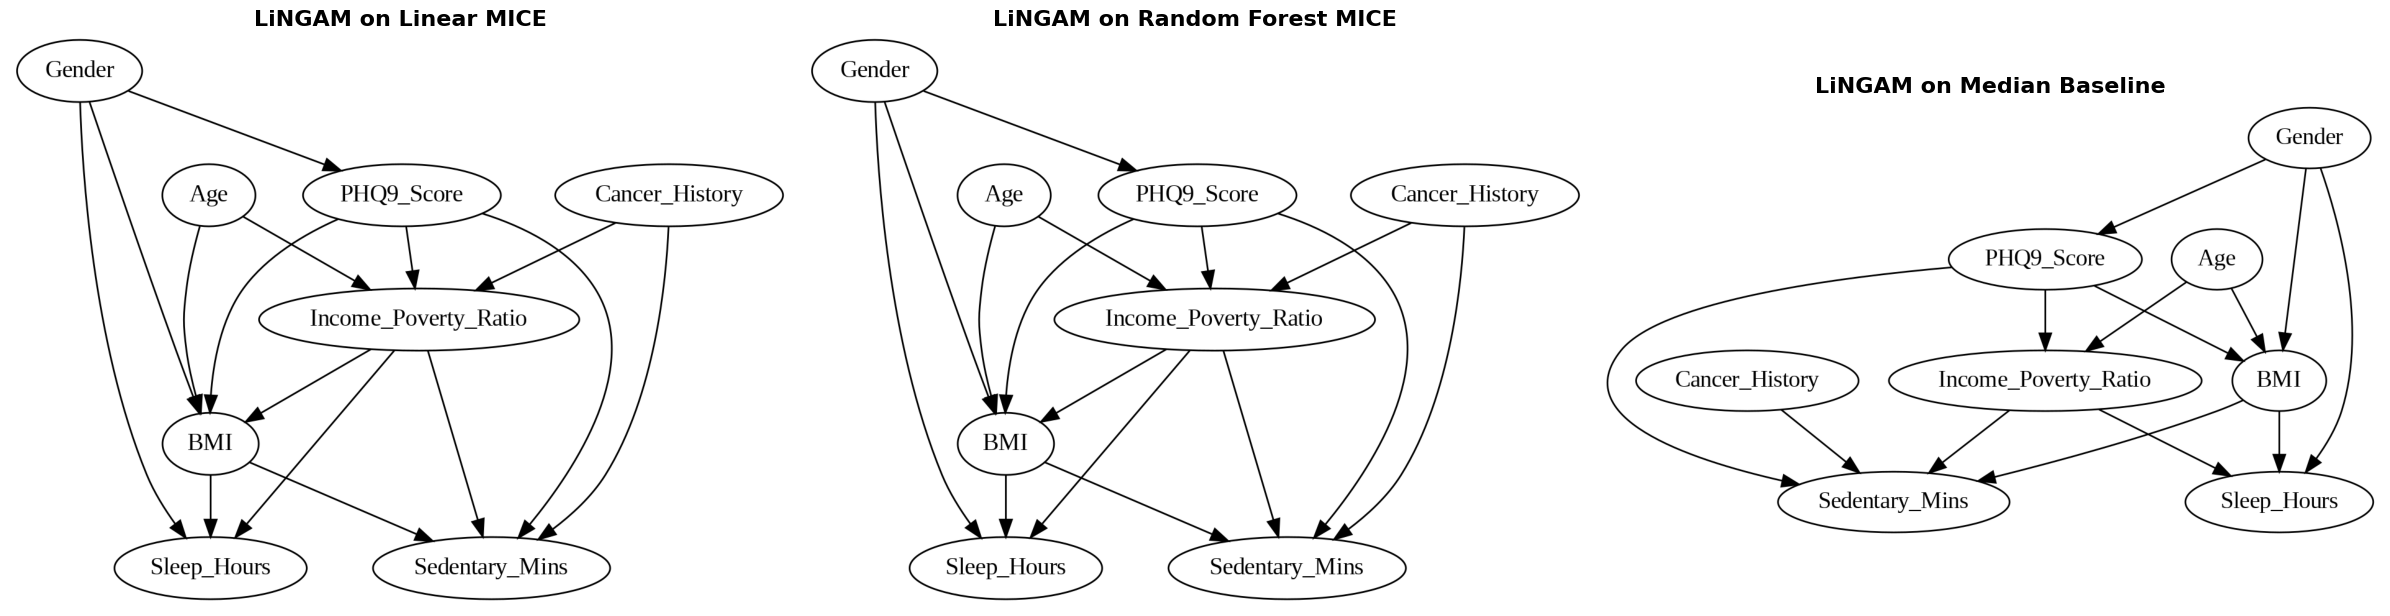

In [ ]:
print("连续得分: LiNGAM 算法...")
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for idx, (name, filename) in enumerate(datasets.items()):
    df = pd.read_csv(os.path.join(drive_data_folder, filename))[selected_nodes]
    df_std = (df - df.mean()) / df.std() # 必须标准化
    data_np = df_std.to_numpy()
    labels = df.columns.tolist()

    model_lingam = lingam.DirectLiNGAM()
    model_lingam.fit(data_np)
    adj_mat = model_lingam.adjacency_matrix_

    # 使用自定义函数转换为标准格式并画图
    G_lingam = matrix_to_cg(labels, adj_mat, "LiNGAM")
    pyd = GraphUtils.to_pydot(G_lingam, labels=labels)
    save_path = os.path.join(drive_data_folder, f'C4_LiNGAM_{name}.png')
    pyd.write_png(save_path)

    img = mpimg.imread(save_path)
    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(f"LiNGAM on {name.replace('_', ' ')}", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()